# Experiment 1: Effect of Model Capacity on Training and Generalization

### Research Question
How does increasing model capacity affect training performance and generalization?

### Experimental Idea
We vary the width of a fully connected neural network while keeping the
architecture depth, dataset, optimizer, learning rate, batch size, and
number of training epochs fixed.

The goal is to investigate whether increasing the number of parameters
necessarily leads to poorer generalization.

### Experimental Configuration

- Dataset: MNIST
- Widths: 16, 32, 64, 128, 256, 512, 1024, 2048
- Optimizer: SGD
- Learning rate: 0.01
- Batch size: 128
- Epochs: 30
- Evaluation metrics: Training accuracy, test accuracy, loss, and generalization gap

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import pandas as pd
import matplotlib.pyplot as plt

import time

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.8MB/s]


In [ ]:
batch_size = 128

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 60000
Test samples: 10000


### Model Architecture

A fully connected neural network with three hidden layers is used:

784 → w → w → w → 10

where `w` represents the width of each hidden layer.

ReLU activation is used after each hidden layer. The output layer
contains 10 neurons corresponding to the 10 MNIST classes.

Only the width is varied across experiments, while the depth and other
training conditions remain fixed.

In [ ]:
class MLP(nn.Module):

    def __init__(self, width):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, 10)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [ ]:
test_widths = [16, 32, 64, 128, 256, 512, 1024, 2048]

for width in test_widths:
    model = MLP(width)
    print(
        f"Width: {width:4d} | "
        f"Parameters: {count_parameters(model):,}"
    )

Width:   16 | Parameters: 13,274
Width:   32 | Parameters: 27,562
Width:   64 | Parameters: 59,210
Width:  128 | Parameters: 134,794
Width:  256 | Parameters: 335,114
Width:  512 | Parameters: 932,362
Width: 1024 | Parameters: 2,913,290
Width: 2048 | Parameters: 10,020,874


### Fixed Training Configuration

The following training conditions are kept constant across all models:

- Optimizer: Stochastic Gradient Descent (SGD)
- Learning rate: 0.01
- Batch size: 128
- Training epochs: 30
- Loss function: Cross-Entropy Loss
- Activation function: ReLU

The only experimental variable is network width.

In [ ]:
learning_rate = 0.01
epochs = 30

criterion = nn.CrossEntropyLoss()

In [ ]:
def train_model(width, epochs=30):

    model = MLP(width).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.01
    )

    history = []

    start_time = time.time()

    for epoch in range(epochs):

        # -------------------------
        # TRAINING
        # -------------------------

        model.train()

        correct = 0
        total = 0
        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)

        train_accuracy = 100 * correct / total


        # -------------------------
        # TESTING
        # -------------------------

        model.eval()

        correct = 0
        total = 0
        test_running_loss = 0.0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / len(test_loader)

        test_accuracy = 100 * correct / total


        # -------------------------
        # STORE RESULTS
        # -------------------------

        history.append({

            "width": width,

            "parameters": count_parameters(model),

            "epoch": epoch + 1,

            "train_loss": train_loss,

            "train_accuracy": train_accuracy,

            "test_loss": test_loss,

            "test_accuracy": test_accuracy

        })


        print(
            f"Width {width} | "
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Acc: {test_accuracy:.2f}%"
        )


    elapsed_time = time.time() - start_time

    print(
        f"Finished width {width} "
        f"in {elapsed_time / 60:.2f} minutes"
    )

    return model, history

### Model Capacities

The following widths are evaluated:

16, 32, 64, 128, 256, 512, 1024, and 2048.

This produces models ranging from approximately 13 thousand to
approximately 10 million trainable parameters.

In [ ]:
widths = [16, 32, 64, 128, 256, 512]

all_history = []

for width in widths:

    print("\n" + "=" * 60)
    print(f"TRAINING MODEL: WIDTH = {width}")
    print("=" * 60)

    model, history = train_model(
        width,
        epochs=30
    )

    all_history.extend(history)


TRAINING MODEL: WIDTH = 16
Width 16 | Epoch 1/30 | Train Acc: 13.67% | Test Acc: 20.40%
Width 16 | Epoch 2/30 | Train Acc: 27.40% | Test Acc: 29.54%
Width 16 | Epoch 3/30 | Train Acc: 38.31% | Test Acc: 52.03%
Width 16 | Epoch 4/30 | Train Acc: 59.78% | Test Acc: 68.79%
Width 16 | Epoch 5/30 | Train Acc: 70.18% | Test Acc: 74.13%
Width 16 | Epoch 6/30 | Train Acc: 75.05% | Test Acc: 78.30%
Width 16 | Epoch 7/30 | Train Acc: 78.36% | Test Acc: 80.31%
Width 16 | Epoch 8/30 | Train Acc: 80.81% | Test Acc: 81.85%
Width 16 | Epoch 9/30 | Train Acc: 82.57% | Test Acc: 83.70%
Width 16 | Epoch 10/30 | Train Acc: 84.17% | Test Acc: 85.20%
Width 16 | Epoch 11/30 | Train Acc: 85.44% | Test Acc: 86.38%
Width 16 | Epoch 12/30 | Train Acc: 86.58% | Test Acc: 86.90%
Width 16 | Epoch 13/30 | Train Acc: 87.69% | Test Acc: 88.38%
Width 16 | Epoch 14/30 | Train Acc: 88.45% | Test Acc: 88.81%
Width 16 | Epoch 15/30 | Train Acc: 89.16% | Test Acc: 89.33%
Width 16 | Epoch 16/30 | Train Acc: 89.61% | Test A

In [ ]:
results_df = pd.DataFrame(all_history)

results_df.to_csv(
    "experiment_1_model_scaling_epoch_results_part1.csv",
    index=False
)

print(results_df.head())

   width  parameters  epoch  train_loss  train_accuracy  test_loss  \
0     16       13274      1    2.299713       13.671667   2.269896   
1     16       13274      2    2.182645       27.401667   2.018349   
2     16       13274      3    1.719571       38.315000   1.396675   
3     16       13274      4    1.128340       59.778333   0.919398   
4     16       13274      5    0.862665       70.181667   0.776622   

   test_accuracy  
0          20.40  
1          29.54  
2          52.03  
3          68.79  
4          74.13  


In [ ]:
widths_large = [1024, 2048]

for width in widths_large:

    print("\n" + "=" * 60)
    print(f"TRAINING MODEL: WIDTH = {width}")
    print("=" * 60)

    model, history = train_model(
        width,
        epochs=30
    )

    all_history.extend(history)


TRAINING MODEL: WIDTH = 1024
Width 1024 | Epoch 1/30 | Train Acc: 43.13% | Test Acc: 53.69%
Width 1024 | Epoch 2/30 | Train Acc: 64.68% | Test Acc: 76.47%
Width 1024 | Epoch 3/30 | Train Acc: 80.72% | Test Acc: 84.84%
Width 1024 | Epoch 4/30 | Train Acc: 86.25% | Test Acc: 87.93%
Width 1024 | Epoch 5/30 | Train Acc: 88.53% | Test Acc: 89.10%
Width 1024 | Epoch 6/30 | Train Acc: 89.70% | Test Acc: 90.32%
Width 1024 | Epoch 7/30 | Train Acc: 90.49% | Test Acc: 91.06%
Width 1024 | Epoch 8/30 | Train Acc: 91.10% | Test Acc: 91.48%
Width 1024 | Epoch 9/30 | Train Acc: 91.64% | Test Acc: 91.79%
Width 1024 | Epoch 10/30 | Train Acc: 92.09% | Test Acc: 92.46%
Width 1024 | Epoch 11/30 | Train Acc: 92.48% | Test Acc: 92.94%
Width 1024 | Epoch 12/30 | Train Acc: 92.87% | Test Acc: 93.30%
Width 1024 | Epoch 13/30 | Train Acc: 93.27% | Test Acc: 93.56%
Width 1024 | Epoch 14/30 | Train Acc: 93.60% | Test Acc: 93.72%
Width 1024 | Epoch 15/30 | Train Acc: 93.96% | Test Acc: 93.82%
Width 1024 | Epoch 

In [ ]:
results_df = pd.DataFrame(all_history)

results_df.to_csv(
    "experiment_1_model_scaling_epoch_results.csv",
    index=False
)

print("Total rows:", len(results_df))

Total rows: 240


In [ ]:
final_results = (
    results_df
    .sort_values("epoch")
    .groupby("width")
    .tail(1)
    .copy()
)

final_results["generalization_gap"] = (
    final_results["train_accuracy"]
    - final_results["test_accuracy"]
)

final_results = final_results.sort_values("width")

final_results

,width,parameters,epoch,train_loss,train_accuracy,test_loss,test_accuracy,generalization_gap
29,16,13274,30,0.243264,93.000000,0.246412,92.85,0.150000
59,32,27562,30,0.177500,94.880000,0.183399,94.51,0.370000
89,64,59210,30,0.146146,95.783333,0.158082,95.19,0.593333
119,128,134794,30,0.140355,95.976667,0.142473,95.62,0.356667
149,256,335114,30,0.125583,96.431667,0.131949,96.00,0.431667
179,512,932362,30,0.126102,96.388333,0.130654,96.20,0.188333
209,1024,2913290,30,0.111924,96.803333,0.120993,96.23,0.573333
239,2048,10020874,30,0.102712,97.081667,0.113486,96.56,0.521667


In [ ]:
final_results[
    [
        "width",
        "parameters",
        "train_loss",
        "train_accuracy",
        "test_loss",
        "test_accuracy",
        "generalization_gap"
    ]
]

,width,parameters,train_loss,train_accuracy,test_loss,test_accuracy,generalization_gap
29,16,13274,0.243264,93.000000,0.246412,92.85,0.150000
59,32,27562,0.177500,94.880000,0.183399,94.51,0.370000
89,64,59210,0.146146,95.783333,0.158082,95.19,0.593333
119,128,134794,0.140355,95.976667,0.142473,95.62,0.356667
149,256,335114,0.125583,96.431667,0.131949,96.00,0.431667
179,512,932362,0.126102,96.388333,0.130654,96.20,0.188333
209,1024,2913290,0.111924,96.803333,0.120993,96.23,0.573333
239,2048,10020874,0.102712,97.081667,0.113486,96.56,0.521667


In [ ]:
final_results.to_csv(
    "experiment_1_model_scaling_final_results.csv",
    index=False
)

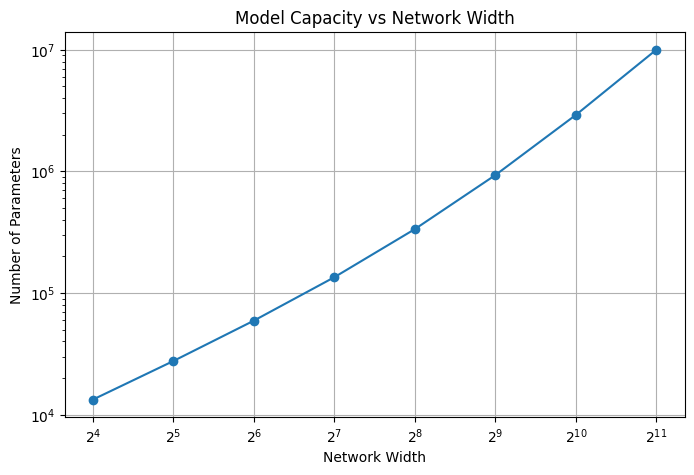

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_results["width"],
    final_results["parameters"],
    marker="o"
)

plt.xscale("log", base=2)
plt.yscale("log")

plt.xlabel("Network Width")
plt.ylabel("Number of Parameters")

plt.title("Model Capacity vs Network Width")

plt.grid(True)

plt.show()

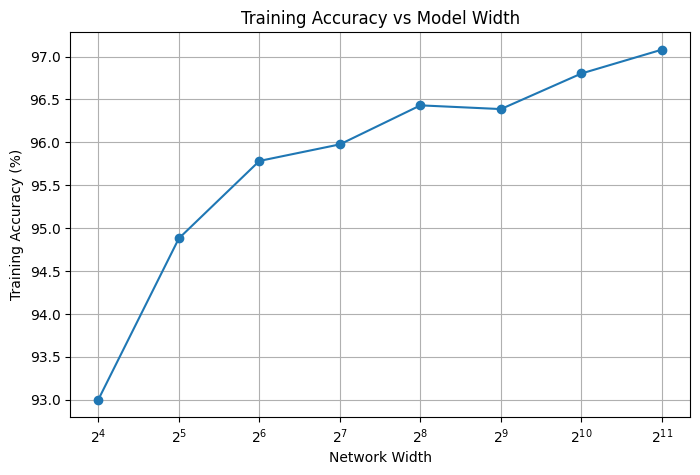

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_results["width"],
    final_results["train_accuracy"],
    marker="o"
)

plt.xscale("log", base=2)

plt.xlabel("Network Width")
plt.ylabel("Training Accuracy (%)")

plt.title("Training Accuracy vs Model Width")

plt.grid(True)

plt.show()

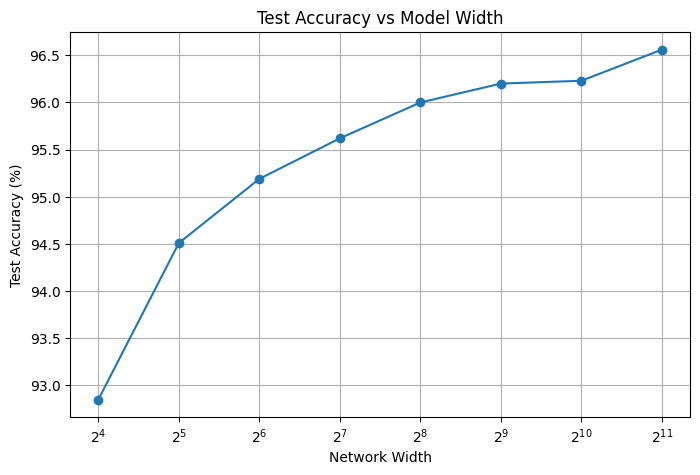

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_results["width"],
    final_results["test_accuracy"],
    marker="o"
)

plt.xscale("log", base=2)

plt.xlabel("Network Width")
plt.ylabel("Test Accuracy (%)")

plt.title("Test Accuracy vs Model Width")

plt.grid(True)

plt.show()

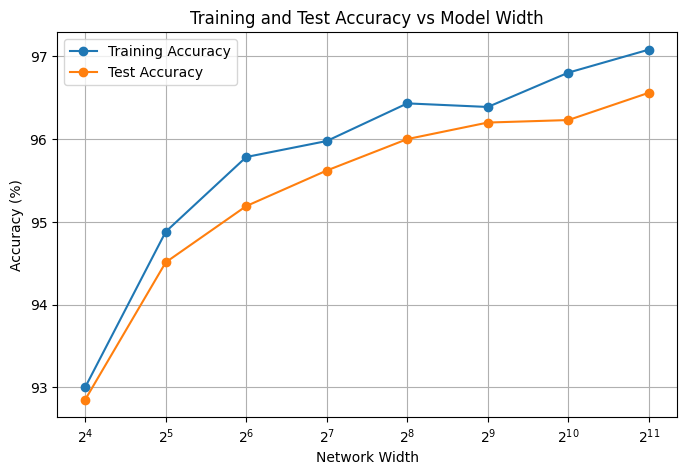

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_results["width"],
    final_results["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    final_results["width"],
    final_results["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xscale("log", base=2)

plt.xlabel("Network Width")
plt.ylabel("Accuracy (%)")

plt.title("Training and Test Accuracy vs Model Width")

plt.legend()

plt.grid(True)

plt.show()

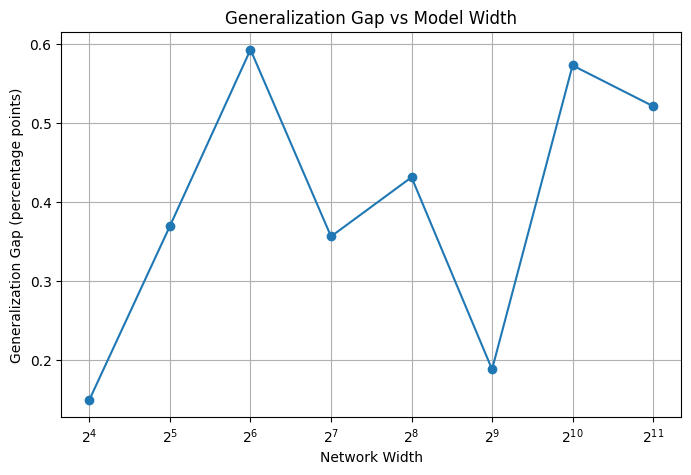

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_results["width"],
    final_results["generalization_gap"],
    marker="o"
)

plt.xscale("log", base=2)

plt.xlabel("Network Width")
plt.ylabel("Generalization Gap (percentage points)")

plt.title("Generalization Gap vs Model Width")

plt.grid(True)

plt.show()

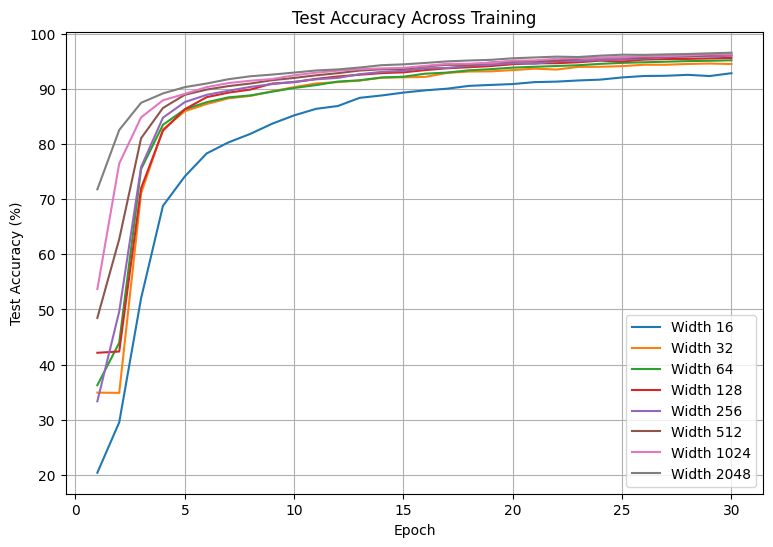

In [ ]:
plt.figure(figsize=(9, 6))

for width in results_df["width"].unique():

    data = results_df[
        results_df["width"] == width
    ]

    plt.plot(
        data["epoch"],
        data["test_accuracy"],
        label=f"Width {width}"
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")

plt.title("Test Accuracy Across Training")

plt.legend()

plt.grid(True)

plt.show()

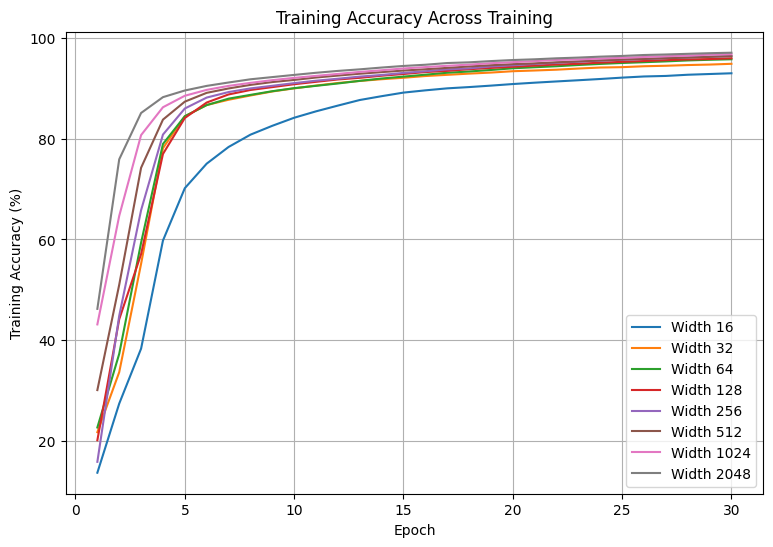

In [ ]:
plt.figure(figsize=(9, 6))

for width in results_df["width"].unique():

    data = results_df[
        results_df["width"] == width
    ]

    plt.plot(
        data["epoch"],
        data["train_accuracy"],
        label=f"Width {width}"
    )

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")

plt.title("Training Accuracy Across Training")

plt.legend()

plt.grid(True)

plt.show()

### Conclusion

Increasing model width generally improved both training and test accuracy in the tested range. Although the generalization gap increased for some larger models, test performance did not show the classical deterioration expected from simple overfitting.

Thus, in this experimental setting, increasing parameter count did not automatically lead to poorer generalization.